# Otimização com PySwarms – Schaffer N.2 (f6), 10 dimensões

Este notebook realiza:
1. Definição da função objetivo f6 para 10 variáveis em batch.
2. Implementação de PSO com loop customizado (Global Best).
3. Registro, a cada iteração, de métricas de aptidão, diversidade e posições.
4. Salvamento dos resultados em arquivos `.npy`.

In [30]:
import time
import os
import glob
import psutil
import numpy as np
import pandas as pd
import pyswarms as ps
from pyswarms.backend.topology import Star
import pyswarms.backend as P
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt

relative = "../"
codes_path = os.path.abspath(relative)

logs_dir = "logs"
result_dir = "results"
pop_dir = "population"
os.makedirs(logs_dir, exist_ok=True)
os.makedirs(result_dir, exist_ok=True)
os.makedirs(pop_dir, exist_ok=True)

# Execução do PSO

In [31]:
# Função objetivo: Schaffer N.2 (f6) para 10 dimensões
# Recebe matriz `X` com shape (n_particles, 10) e retorna vetor de aptidões.
def f6_v10_max(X):
    term = np.sum(X**2, axis=1)
    num = np.sin(np.sqrt(term))**2 - 0.5
    denom = (1 + 0.001 * term)**2
    return -1*(0.5 - num / denom)

In [32]:
n_particles = 500
dimensions = 10
options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
max_iters = 500
bounds = (np.full(dimensions, -100), np.full(dimensions, 100)) 

In [33]:
# Loop de otimização personalizado #
# Em cada iteração:
# - Computa o custo atual.
# - Atualiza pbest e gbest.
# - Calcula estatísticas.
# - Atualiza velocidade e posição de cada partícula.

for run in range(1, 17):
    print(f"\nRodada {run}:")
    start_run_time = time.time()
    total_time = 0

    process = psutil.Process(os.getpid())
    process.cpu_percent(interval=None)
    
    iteration_logs = []
    # Posições serão salvas diretamente
    positions = np.zeros((max_iters, n_particles, dimensions))

    # Criação do enxame (Global Best) com topologia Star
    topology = Star()
    swarm = P.create_swarm(n_particles=n_particles, dimensions=dimensions, options=options, bounds=bounds)

    # Inicialização de custos pessoais e global
    swarm.pbest_cost = np.full(n_particles, np.inf)
    swarm.best_cost = np.inf
    
    for gen in range(max_iters):
        start_gen_time = time.time()
        
        swarm.current_cost = f6_v10_max(swarm.position)
        swarm.pbest_pos, swarm.pbest_cost = P.compute_pbest(swarm)
    
        if np.min(swarm.pbest_cost) < swarm.best_cost:
            swarm.best_pos, swarm.best_cost = topology.compute_gbest(swarm)
    
        # Cálculo de estatísticas
        best_cost = -swarm.best_cost
        mean_cost = -np.mean(swarm.current_cost)
        min_cost = -np.max(swarm.current_cost)
    
        # Diversidade média: distância euclidiana média entre partículas
        distances = pdist(swarm.position, metric='euclidean')
        mean_diversity = np.mean(distances)

        # Tempo e recursos
        gen_time = time.time() - start_gen_time
        total_time += gen_time
        cpu_percent = process.cpu_percent(interval=None)/psutil.cpu_count()  
        mem_used = process.memory_info().rss / (1024 ** 2)

        iteration_logs.append({
            "run": run,
            "generation": gen+1,
            "min_fitness": min_cost,
            "mean_fitness": mean_cost,
            "max_fitness": best_cost,
            "mean_diversity": mean_diversity,
            "total_time": total_time
        })
        
        positions[gen] = swarm.position.copy()
    
        # Atualiza velocidade e posição
        swarm.velocity = topology.compute_velocity(swarm)
        swarm.position = topology.compute_position(swarm)
    
        # Log de progresso (opcional)
        if (gen+1) % 50 == 0:
            print(f"Run {run}, Iter {gen+1}/{max_iters}: " +
                  f"Best = {best_cost:.5f}, Mean = {mean_cost:.5f}, Min = {min_cost:.5f}, mean diversity = {mean_diversity:.2f}")
            
    result_logs = pd.DataFrame(iteration_logs)
    result_logs.to_csv(f"{logs_dir}/logs_run_{run}.csv", index=False)
    np.save(f"{pop_dir}/positions_run_{run}.npy", positions)


Rodada 1:
Run 1, Iter 50/500: Best = 0.99028, Mean = 0.52977, Min = 0.02150, mean diversity = 11.71
Run 1, Iter 100/500: Best = 0.99028, Mean = 0.72218, Min = 0.02159, mean diversity = 3.49
Run 1, Iter 150/500: Best = 0.99028, Mean = 0.85206, Min = 0.02197, mean diversity = 2.32
Run 1, Iter 200/500: Best = 0.99028, Mean = 0.89372, Min = 0.02065, mean diversity = 1.94
Run 1, Iter 250/500: Best = 0.99028, Mean = 0.91772, Min = 0.02147, mean diversity = 1.60
Run 1, Iter 300/500: Best = 0.99028, Mean = 0.92128, Min = 0.02147, mean diversity = 1.43
Run 1, Iter 350/500: Best = 0.99028, Mean = 0.93469, Min = 0.02151, mean diversity = 1.34
Run 1, Iter 400/500: Best = 0.99028, Mean = 0.93773, Min = 0.00703, mean diversity = 1.26
Run 1, Iter 450/500: Best = 0.99028, Mean = 0.95066, Min = 0.02161, mean diversity = 1.16
Run 1, Iter 500/500: Best = 0.99028, Mean = 0.94716, Min = 0.02525, mean diversity = 1.13

Rodada 2:
Run 2, Iter 50/500: Best = 0.99028, Mean = 0.51284, Min = 0.02153, mean divers

# Agregação de dados do PSO, AG Real e Estratégias Evolutivas

In [34]:
log_dfs = {}

logs_list = sorted(glob.glob(os.path.join(logs_dir, f"logs_run_*.csv")))
df_list = [pd.read_csv(f) for f in logs_list]
df_total = pd.concat(df_list, ignore_index=True)
df_total.replace([np.inf, -np.inf], np.nan, inplace=True)
df_total = df_total.interpolate()
log_dfs[f'PSO'] = df_total

In [35]:
def calc_diversity(npz_path, representation, decode_func=None):
    """
    Calcula a diversidade genotípica por geração.

    Parâmetros:
    - npz_path: caminho para o arquivo .npz contendo populações salvas
    - representation: 'binary' ou 'real'
    - decode_func: função para decodificar indivíduos binários para fenótipo (obrigatória se binário)

    Retorna:
    - dict com 'genotypic' contendo valores médios, mínimos e máximos por geração
    """
    data = np.load(npz_path, allow_pickle=True)
    results = {
        "genotypic": {"mean": [], "min": [], "max": []}
    }

    sorted_keys = sorted(data.keys(), key=lambda x: int(x.split('_')[1]))

    for key in sorted_keys:
        pop = data[key]
        pop = np.array(pop)

        # GENOTIPO
        if representation == 'binary':
            # Distância de Hamming normalizada
            dists = [np.mean(p1 != p2) for p1, p2 in combinations(pop, 2)]
        else:  # real
            # Distância Euclidiana
            dists = pdist(pop, metric='euclidean')

        results["genotypic"]["mean"].append(np.mean(dists))
        results["genotypic"]["min"].append(np.min(dists))
        results["genotypic"]["max"].append(np.max(dists))

    return results

In [39]:
ag_pops_dir = f'{codes_path}/trabalho8/populations/model4_run_*_populations.npz'
pop_list = sorted(glob.glob(ag_pops_dir))
div_list = [calc_diversity(pop, 'real') for pop in pop_list]

df_total = pd.DataFrame([])
for diversity_dict in div_list:
    gen = 1
    for value in diversity_dict['genotypic']['mean']:
        n_row = pd.Series({'generation': np.int32(gen), 'mean_diversity': value}).to_frame().T
        df_total = pd.concat([df_total,n_row], ignore_index=True)
        gen += 1

ag_logs_dir = f'{codes_path}/trabalho8/logs/model4_run_*_logs.csv'
ag_logs_list = sorted(glob.glob(ag_logs_dir))
ag_df_list = [pd.read_csv(f) for f in ag_logs_list]
ag_df_total = pd.concat(ag_df_list, ignore_index=True)
ag_df_total = ag_df_total[['min_fitness','mean_fitness','max_fitness','total_time']]

ag_df_total = pd.merge(ag_df_total, df_total, left_index=True, right_index=True)

log_dfs['AG Real'] = ag_df_total

In [37]:
strategy = 1

configs = {
    "EE-(μ+λ)": dict(mu=200, lam=400, rho=1, generations=500, selection_type="+"),
    "EE-(μ+μ)": dict(mu=200, lam=200, rho=1, generations=500, selection_type="+"),
    "EE-(λ+μ)": dict(mu=400, lam=200, rho=1, generations=500, selection_type="+"),
    "EE-(μ/ρ+1)": dict(mu=200, lam=200, rho=3, generations=500, selection_type="+"),
    "EE-(μ,λ)": dict(mu=200, lam=400, rho=1, generations=500, selection_type=","),
    "EE-(μ/ρ,λ)": dict(mu=200, lam=400, rho=3, generations=500, selection_type=","),
}

for label in configs.keys():
    ee_logs_dir = f"{codes_path}/trabalho10/logs"
    strat_dir = f"strategy_{strategy}/strategy_{strategy}_run_*.csv"
    logs_list = sorted(glob.glob(os.path.join(ee_logs_dir, strat_dir)))
    df_list = [pd.read_csv(f) for f in logs_list]
    df_total = pd.concat(df_list, ignore_index=True)
    df_total.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_total = df_total.interpolate()
    log_dfs[label] = df_total
    strategy += 1

In [40]:
aggregated_data = {}

for label, df in log_dfs.items():
    if not df.empty:
        grouped = df.groupby('generation').agg({
            'min_fitness': ['mean', 'std'],
            'mean_fitness': ['mean', 'std'],
            'max_fitness': ['mean', 'std'],
            'mean_diversity': ['mean', 'std'],
            'total_time': ['mean', 'std']
        })
        grouped.columns = ['_'.join(col).strip() for col in grouped.columns.values]
        aggregated_data[label] = grouped
    else:
        aggregated_data[label] = pd.DataFrame() 

# Visualização dos Resultados

In [13]:
def plot_performance(data, metric, title, ylabel, filename_prefix):
    plt.figure(figsize=(12, 7))
    for label, df_agg in data.items():
        if not df_agg.empty:
            mean_col = f'{metric}_mean'
            std_col = f'{metric}_std'
            
            if mean_col in df_agg.columns and std_col in df_agg.columns:
                plt.plot(df_agg.index, df_agg[mean_col], label=label)
                plt.fill_between(df_agg.index, 
                                 df_agg[mean_col] - df_agg[std_col],
                                 df_agg[mean_col] + df_agg[std_col],
                                 alpha=0.2)
            else:
                print(f"Aviso: Colunas {mean_col} ou {std_col} não encontradas para {label}.")
        else:
            print(f"Aviso: Dados agregados vazios para {label}. Ignorando plotagem para esta estratégia.")

    plt.title(title)
    plt.xlabel("Geração")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{result_dir}/{filename_prefix}.png")
    plt.show()

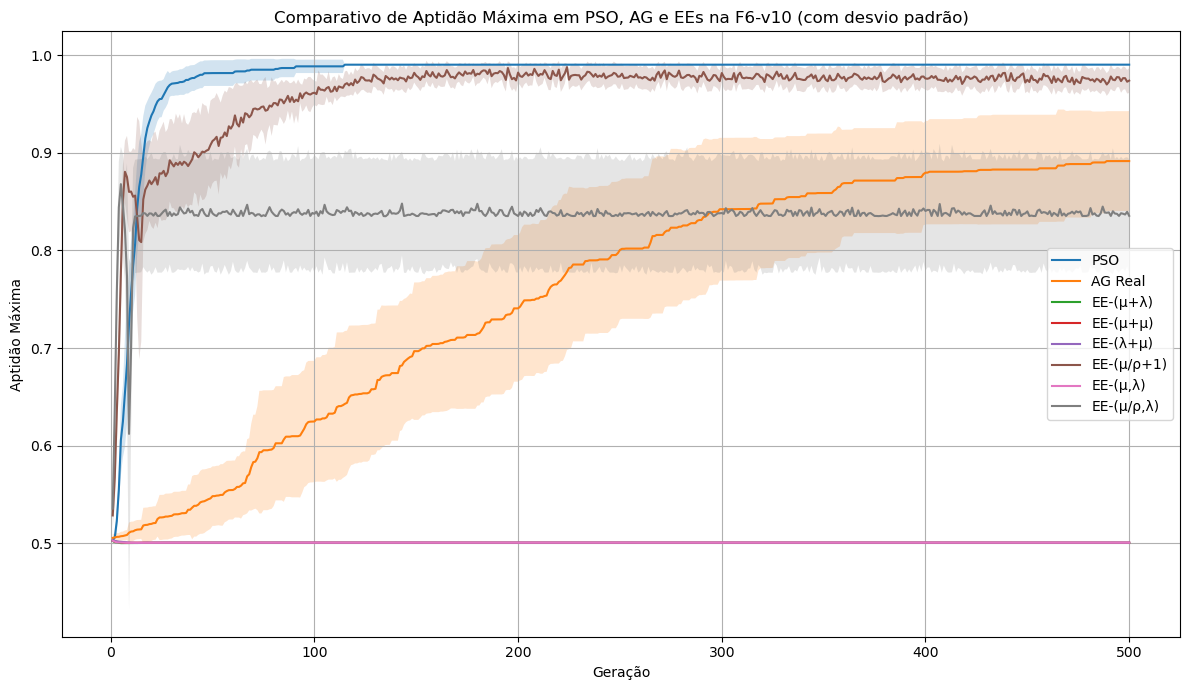

In [13]:
plot_performance(aggregated_data, "max_fitness", 
                 "Comparativo de Aptidão Máxima em PSO, AG e EEs na F6-v10 (com desvio padrão)", 
                 "Aptidão Máxima", "PSO_max-fit_std")

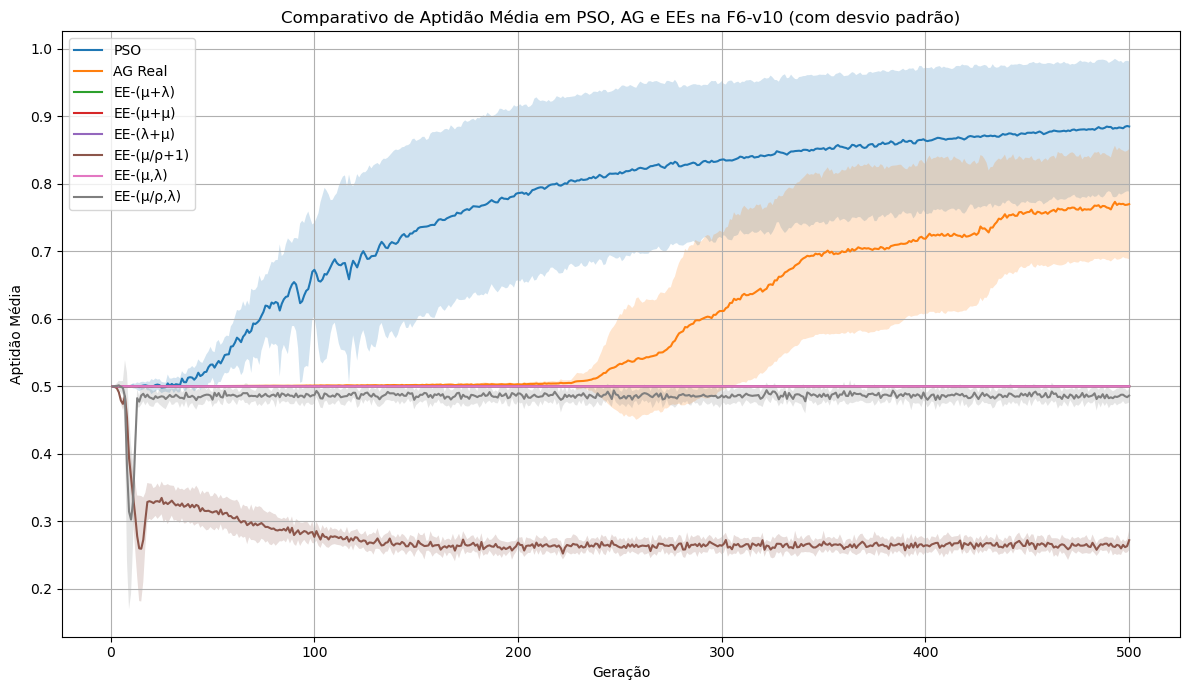

In [14]:
plot_performance(aggregated_data, "mean_fitness", 
                 "Comparativo de Aptidão Média em PSO, AG e EEs na F6-v10 (com desvio padrão)", 
                 "Aptidão Média", "PSO_mean-fit_std")

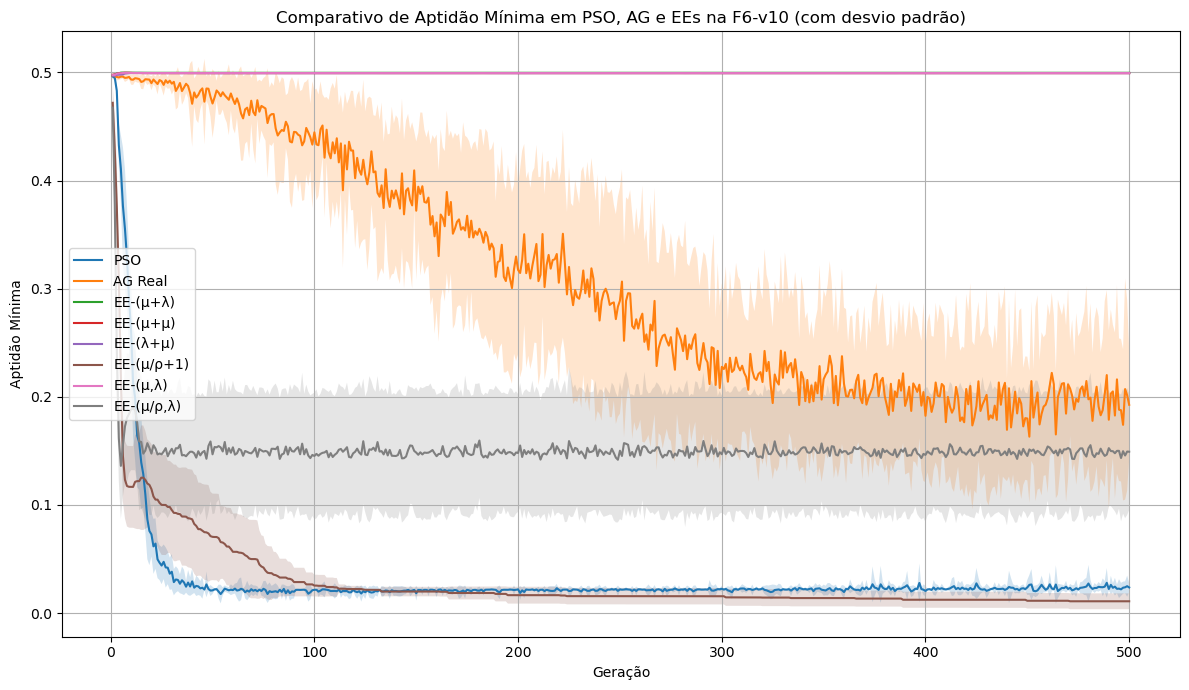

In [15]:
plot_performance(aggregated_data, "min_fitness", 
                 "Comparativo de Aptidão Mínima em PSO, AG e EEs na F6-v10 (com desvio padrão)", 
                 "Aptidão Mínima", "PSO_min-fit_std")

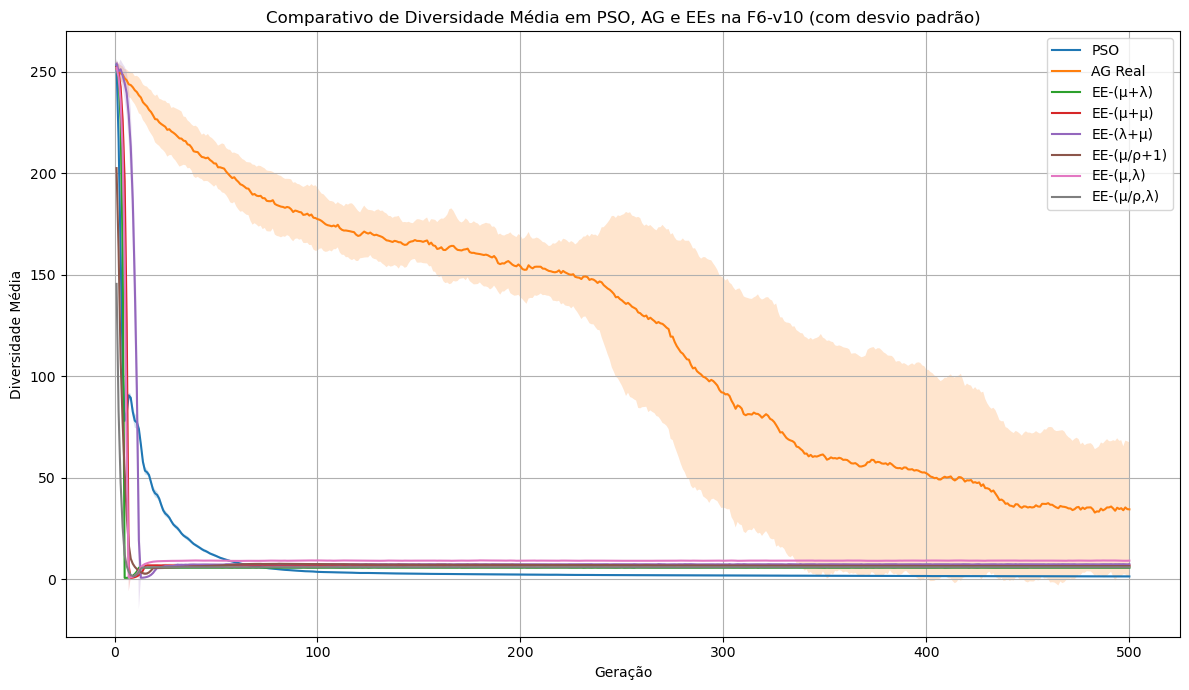

In [16]:
plot_performance(aggregated_data, "mean_diversity", 
                 "Comparativo de Diversidade Média em PSO, AG e EEs na F6-v10 (com desvio padrão)", 
                 "Diversidade Média", "PSO_mean-diversity_std")

In [ ]:
# Plotar Diversidade Média
plot_performance(aggregated_data, "mean_diversity", 
                 "Comparativo de Tempo Total de Exe em PSO, AG e EEs na F6-v10 (com desvio padrão)", 
                 "Diversidade Média", "PSO_mean-diversity_std")